# 🏭 Supply Chain Inventory Simulation
### Agent-Based Model using Mesa 3.x

**Agents:** `SupplierAgent` · `RetailerAgent` · `CustomerAgent`

**Next step:** Replace the RetailerAgent rule-based policy with an LLM-powered agentic workflow.

In [1]:
# ── CELL 1: Install dependencies
!pip install mesa matplotlib pandas -q

error: externally-managed-environment

× This environment is externally managed
╰─> To install Python packages system-wide, try apt install
    python3-xyz, where xyz is the package you are trying to
    install.
    
    If you wish to install a non-Debian-packaged Python package,
    create a virtual environment using python3 -m venv path/to/venv.
    Then use path/to/venv/bin/python and path/to/venv/bin/pip. Make
    sure you have python3-full installed.
    
    If you wish to install a non-Debian packaged Python application,
    it may be easiest to use pipx install xyz, which will manage a
    virtual environment for you. Make sure you have pipx installed.
    
    See /usr/share/doc/python3.12/README.venv for more information.

note: If you believe this is a mistake, please contact your Python installation or OS distribution provider. You can override this, at the risk of breaking your Python installation or OS, by passing --break-system-packages.
hint: See PEP 668 for the detai

In [2]:
# ── CELL 2: Imports
import random
import os
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import pandas as pd
from mesa import Agent, Model
from mesa.datacollection import DataCollector

os.makedirs('outputs', exist_ok=True)
print('✅ Imports OK')

✅ Imports OK


In [3]:
# ── CELL 3: Agent & Model definitions (Mesa 3.x — no RandomActivation)

class CustomerAgent(Agent):
    def __init__(self, model, mean_demand=20, std_demand=5):
        super().__init__(model)
        self.mean_demand = mean_demand
        self.std_demand = std_demand
        self.daily_demand = 0
    def step(self):
        self.daily_demand = max(0, int(random.gauss(self.mean_demand, self.std_demand)))


class SupplierAgent(Agent):
    def __init__(self, model, capacity=600):
        super().__init__(model)
        self.capacity = capacity
        self.pending_orders = []
        self.total_shipped = 0
    def receive_order(self, retailer, qty, lead_time):
        due_day = self.model.steps + lead_time
        self.pending_orders.append((retailer, qty, due_day))
    def step(self):
        current_day = self.model.steps
        remaining = self.capacity
        still_pending = []
        for (retailer, qty, due_day) in self.pending_orders:
            if due_day <= current_day and remaining > 0:
                shipped = min(qty, remaining)
                retailer.receive_shipment(shipped)
                remaining -= shipped
                self.total_shipped += shipped
                if shipped < qty:
                    still_pending.append((retailer, qty - shipped, due_day + 1))
            else:
                still_pending.append((retailer, qty, due_day))
        self.pending_orders = still_pending


class RetailerAgent(Agent):
    def __init__(self, model, supplier,
                 initial_inventory=400, reorder_point=300, order_up_to=800,
                 lead_time=3, holding_cost=1.0, backlog_cost=5.0):
        super().__init__(model)
        self.supplier = supplier
        self.inventory = initial_inventory
        self.reorder_point = reorder_point
        self.order_up_to = order_up_to
        self.lead_time = lead_time
        self.holding_cost = holding_cost
        self.backlog_cost = backlog_cost
        self.backlog = 0
        self.total_holding_cost = 0.0
        self.total_backlog_cost = 0.0
        self.total_sales = 0
        self.order_placed_today = False
    def receive_shipment(self, qty):
        self.inventory += qty
        self.backlog -= min(self.backlog, qty)
    def step(self):
        total_demand = sum(c.daily_demand for c in self.model.agents
                           if isinstance(c, CustomerAgent))
        fulfilled = min(total_demand, self.inventory)
        self.total_sales += fulfilled
        self.inventory -= fulfilled
        self.backlog += total_demand - fulfilled
        self.total_holding_cost += self.inventory * self.holding_cost
        self.total_backlog_cost += self.backlog * self.backlog_cost
        self.order_placed_today = False
        if self.inventory < self.reorder_point:
            self.supplier.receive_order(self, self.order_up_to - self.inventory, self.lead_time)
            self.order_placed_today = True


class SupplyChainModel(Model):
    def __init__(self, n_customers=5, mean_demand=20, std_demand=5,
                 reorder_point=300, order_up_to=800, lead_time=3,
                 supplier_cap=600, seed=42):
        super().__init__(rng=seed)
        random.seed(seed)
        self.supplier = SupplierAgent(self, capacity=supplier_cap)
        self.retailer = RetailerAgent(self, self.supplier,
                                      reorder_point=reorder_point,
                                      order_up_to=order_up_to,
                                      lead_time=lead_time)
        for _ in range(n_customers):
            CustomerAgent(self, mean_demand=mean_demand, std_demand=std_demand)
        self.datacollector = DataCollector(model_reporters={
            'Inventory':   lambda m: m.retailer.inventory,
            'Backlog':     lambda m: m.retailer.backlog,
            'HoldingCost': lambda m: m.retailer.total_holding_cost,
            'BacklogCost': lambda m: m.retailer.total_backlog_cost,
            'TotalDemand': lambda m: sum(c.daily_demand for c in m.agents
                                         if isinstance(c, CustomerAgent)),
            'OrderPlaced': lambda m: int(m.retailer.order_placed_today),
        })
    def step(self):
        self.datacollector.collect(self)
        self.agents.do('step')
    def run(self, steps=90):
        for _ in range(steps):
            self.step()
        return self.datacollector.get_model_vars_dataframe()

print('✅ Agents and Model defined (Mesa 3.x compatible)!')

✅ Agents and Model defined (Mesa 3.x compatible)!


In [4]:
# ── CELL 4: Run baseline simulation
model = SupplyChainModel(
    n_customers=5, mean_demand=20, std_demand=5,
    reorder_point=300, order_up_to=800,
    lead_time=3, supplier_cap=600, seed=42
)
df = model.run(steps=90)
df.index.name = 'Day'

print('KPI Summary')
print('-' * 40)
print(f"Avg Inventory   : {df['Inventory'].mean():.1f} units")
print(f"Avg Backlog     : {df['Backlog'].mean():.1f} units")
print(f"Total Cost      : ${df['HoldingCost'].iloc[-1] + df['BacklogCost'].iloc[-1]:,.0f}")
print(f"Service Level   : {100*(1-(df['Backlog']>0).mean()):.1f}%")
print(f"Orders Placed   : {df['OrderPlaced'].sum()} times")

KPI Summary
----------------------------------------
Avg Inventory   : 847.7 units
Avg Backlog     : 0.0 units
Total Cost      : $75,897
Service Level   : 100.0%
Orders Placed   : 15 times


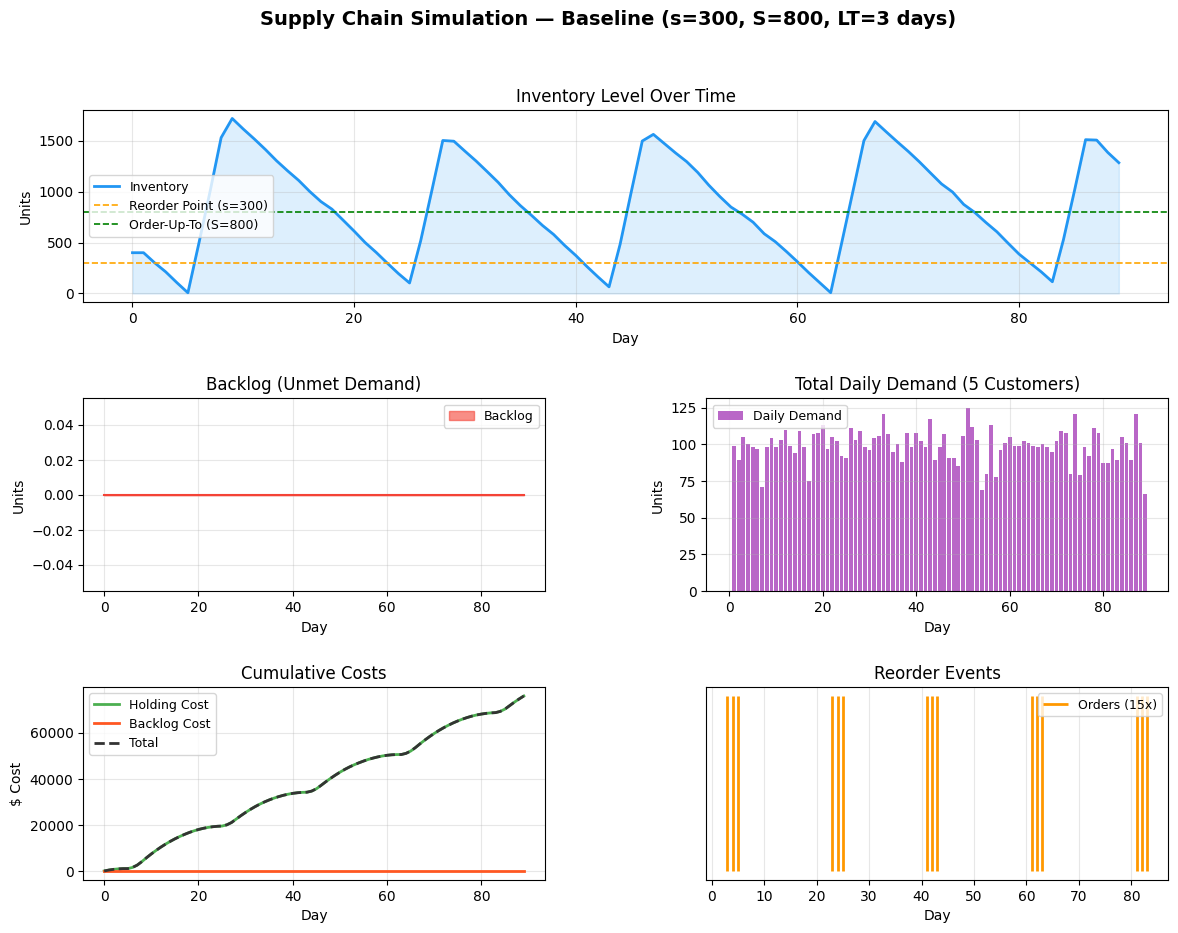

📊 Chart saved → outputs/simulation_results.png


In [5]:
# ── CELL 5: Visualise baseline results
fig = plt.figure(figsize=(14, 10))
fig.suptitle('Supply Chain Simulation — Baseline (s=300, S=800, LT=3 days)',
             fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.5, wspace=0.35)

ax1 = fig.add_subplot(gs[0, :])
ax1.plot(df.index, df['Inventory'], color='#2196F3', linewidth=2, label='Inventory')
ax1.axhline(300, color='orange', linestyle='--', linewidth=1.2, label='Reorder Point (s=300)')
ax1.axhline(800, color='green', linestyle='--', linewidth=1.2, label='Order-Up-To (S=800)')
ax1.fill_between(df.index, 0, df['Inventory'], alpha=0.15, color='#2196F3')
ax1.set_title('Inventory Level Over Time')
ax1.set_ylabel('Units'); ax1.set_xlabel('Day')
ax1.legend(fontsize=9); ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(df.index, df['Backlog'], color='#F44336', alpha=0.6, label='Backlog')
ax2.plot(df.index, df['Backlog'], color='#F44336', linewidth=1.5)
ax2.set_title('Backlog (Unmet Demand)')
ax2.set_ylabel('Units'); ax2.set_xlabel('Day')
ax2.legend(fontsize=9); ax2.grid(True, alpha=0.3)

ax3 = fig.add_subplot(gs[1, 1])
ax3.bar(df.index, df['TotalDemand'], color='#9C27B0', alpha=0.7, label='Daily Demand')
ax3.set_title('Total Daily Demand (5 Customers)')
ax3.set_ylabel('Units'); ax3.set_xlabel('Day')
ax3.legend(fontsize=9); ax3.grid(True, alpha=0.3)

ax4 = fig.add_subplot(gs[2, 0])
ax4.plot(df.index, df['HoldingCost'], color='#4CAF50', linewidth=2, label='Holding Cost')
ax4.plot(df.index, df['BacklogCost'], color='#FF5722', linewidth=2, label='Backlog Cost')
ax4.plot(df.index, df['HoldingCost']+df['BacklogCost'], color='#333', linewidth=2, linestyle='--', label='Total')
ax4.set_title('Cumulative Costs')
ax4.set_ylabel('$ Cost'); ax4.set_xlabel('Day')
ax4.legend(fontsize=9); ax4.grid(True, alpha=0.3)

ax5 = fig.add_subplot(gs[2, 1])
order_days = df[df['OrderPlaced']==1].index
ax5.vlines(order_days, 0, 1, color='#FF9800', linewidth=2, label=f'Orders ({len(order_days)}x)')
ax5.set_title('Reorder Events')
ax5.set_xlabel('Day'); ax5.set_yticks([])
ax5.legend(fontsize=9); ax5.grid(True, alpha=0.3)

plt.savefig('outputs/simulation_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('📊 Chart saved → outputs/simulation_results.png')

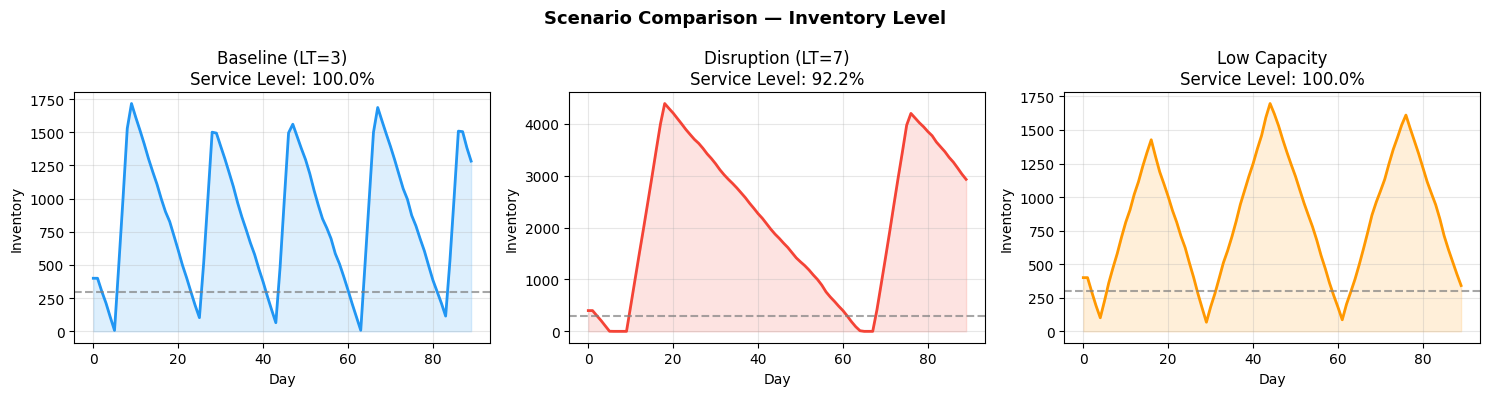

✅ All scenarios done!


In [6]:
# ── CELL 6: Scenario comparison
scenarios = {
    'Baseline (LT=3)':   SupplyChainModel(lead_time=3, seed=42),
    'Disruption (LT=7)': SupplyChainModel(lead_time=7, seed=42),
    'Low Capacity':      SupplyChainModel(lead_time=3, supplier_cap=200, seed=42),
}
fig2, axes = plt.subplots(1, 3, figsize=(15, 4))
fig2.suptitle('Scenario Comparison — Inventory Level', fontsize=13, fontweight='bold')
colors = ['#2196F3', '#F44336', '#FF9800']
for ax, (name, m), color in zip(axes, scenarios.items(), colors):
    r = m.run(steps=90)
    ax.plot(r.index, r['Inventory'], color=color, linewidth=2)
    ax.axhline(300, color='gray', linestyle='--', alpha=0.7)
    ax.fill_between(r.index, 0, r['Inventory'], alpha=0.15, color=color)
    svc = 100*(1-(r['Backlog']>0).mean())
    ax.set_title(f'{name}\nService Level: {svc:.1f}%')
    ax.set_ylabel('Inventory'); ax.set_xlabel('Day'); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/scenario_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ All scenarios done!')

## 🚀 Next Step: LLM Agent Integration

The `RetailerAgent.step()` currently uses a hard-coded **(s, S)** rule.  
The next phase replaces this with an **LLM-powered decision loop**:

```python
prompt = f"""
Current inventory: {self.inventory} units
Current backlog: {self.backlog} units
Lead time: {self.lead_time} days

Should I place an order today? If yes, how many units?
Think step by step.
"""
decision = llm.invoke(prompt)  # Chain-of-Thought reasoning
```